In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re, warnings, time
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, RandomizedSearchCV,
                                     cross_val_score, StratifiedKFold, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from scipy.stats import randint, uniform

# ── White background style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#CCCCCC',
    'axes.labelcolor':  '#222222',
    'xtick.color':      '#444444',
    'ytick.color':      '#444444',
    'text.color':       '#222222',
    'grid.color':       '#DDDDDD',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
})

PHISH_COLOR = '#E63946'
LEGIT_COLOR = '#2A9D8F'
PALETTE     = [LEGIT_COLOR, PHISH_COLOR]
COLORS      = [LEGIT_COLOR, PHISH_COLOR, '#457B9D', '#F4A261', '#6A4C93']

# ── Load datasets ────────────────────────────────────────────────────
df1 = pd.read_csv("Dataset.csv")
df2 = pd.read_csv("dataset_phishing.csv")
df3 = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

print(f"D1 shape: {df1.shape}")
print(f"D2 shape: {df2.shape}")
print(f"D3 shape: {df3.shape}")
print("\nD1 columns:", df1.columns.tolist())
print("\nD2 columns:", df2.columns.tolist())
print("\nD3 columns:", df3.columns.tolist())


D1 shape: (77891, 42)
D2 shape: (11430, 89)
D3 shape: (31225, 56)

D1 columns: ['Type', 'url_length', 'number_of_dots_in_url', 'having_repeated_digits_in_url', 'number_of_digits_in_url', 'number_of_special_char_in_url', 'number_of_hyphens_in_url', 'number_of_underline_in_url', 'number_of_slash_in_url', 'number_of_questionmark_in_url', 'number_of_equal_in_url', 'number_of_at_in_url', 'number_of_dollar_in_url', 'number_of_exclamation_in_url', 'number_of_hashtag_in_url', 'number_of_percent_in_url', 'domain_length', 'number_of_dots_in_domain', 'number_of_hyphens_in_domain', 'having_special_characters_in_domain', 'number_of_special_characters_in_domain', 'having_digits_in_domain', 'number_of_digits_in_domain', 'having_repeated_digits_in_domain', 'number_of_subdomains', 'having_dot_in_subdomain', 'having_hyphen_in_subdomain', 'average_subdomain_length', 'average_number_of_dots_in_subdomain', 'average_number_of_hyphens_in_subdomain', 'having_special_characters_in_subdomain', 'number_of_specia

## Label Standardization & URL Normalization

In [ ]:
# ── STEP 1: Standardize labels to 0/1 ───────────────────────────────
print("D1 'Type' unique values  :", df1['Type'].unique())
print("D2 'status' unique values:", df2['status'].unique())
print("D3 'label' unique values :", df3['label'].unique())

label_map = {0: 0, 1: 1, 'legitimate': 0, 'phishing': 1,
             'Legitimate': 0, 'Phishing': 1}

df1['label'] = df1['Type'].map(label_map)
df2['label'] = df2['status'].map(label_map)
df3['label'] = df3['label'].map(label_map)

print("\nLabel distribution after standardization:")
print(f"  D1: {df1['label'].value_counts().to_dict()}")
print(f"  D2: {df2['label'].value_counts().to_dict()}")
print(f"  D3: {df3['label'].value_counts().to_dict()}")

# ── STEP 2: Normalize URLs for joining ──────────────────────────────
def normalize_url(url):
    url = str(url).strip().lower()
    url = re.sub(r'^https?://', '', url)
    url = re.sub(r'^www\.', '', url)
    url = url.rstrip('/')
    return url

df2['url_key'] = df2['url'].apply(normalize_url)
df3['url_key'] = df3['URL'].apply(normalize_url)

overlap = set(df2['url_key']) & set(df3['url_key'])
print(f"\nD2 unique URLs : {df2['url_key'].nunique():,}")
print(f"D3 unique URLs : {df3['url_key'].nunique():,}")
print(f"Overlapping    : {len(overlap):,}")
print(f"Overlap %      : {len(overlap)/df2['url_key'].nunique()*100:.1f}% of D2")


D1 'Type' unique values  : [0 1]
D2 'status' unique values: ['legitimate' 'phishing']
D3 'label' unique values : [ 1.  0. nan]

Label distribution after standardization:
  D1: {0: 40340, 1: 37551}
  D2: {0: 5715, 1: 5715}
  D3: {1.0: 18533, 0.0: 12691}

D2 unique URLs : 11,070
D3 unique URLs : 31,166
Overlapping    : 30
Overlap %      : 0.3% of D2


## Column Renaming & Dataset Merging

In [ ]:
# ── STEP 3: Rename semantically equivalent columns ───────────────────
df2 = df2.rename(columns={
    'length_url'      : 'url_length',
    'length_hostname' : 'domain_length',
    'nb_dots'         : 'nb_dots_url',
    'nb_hyphens'      : 'nb_hyphens_url',
    'nb_at'           : 'nb_at_url',
    'nb_slash'        : 'nb_slash_url',
    'nb_qm'           : 'nb_qm_url',
    'nb_eq'           : 'nb_eq_url',
    'nb_dollar'       : 'nb_dollar_url',
    'nb_percent'      : 'nb_percent_url',
    'nb_underscore'   : 'nb_underscore_url',
    'nb_subdomains'   : 'nb_subdomains',
    'nb_and'          : 'nb_ampersand_url',
})

df3 = df3.rename(columns={
    'URLLength'         : 'url_length',
    'DomainLength'      : 'domain_length',
    'NoOfSubDomain'     : 'nb_subdomains',
    'NoOfQMarkInURL'    : 'nb_qm_url',
    'NoOfEqualsInURL'   : 'nb_eq_url',
    'NoOfAmpersandInURL': 'nb_ampersand_url',
    'IsDomainIP'        : 'ip',
    'IsHTTPS'           : 'https_token',
    'NoOfURLRedirect'   : 'nb_redirection',
    'NoOfiFrame'        : 'iframe',
    'NoOfPopup'         : 'popup_window',
})

df1 = df1.rename(columns={
    'number_of_dots_in_url'        : 'nb_dots_url',
    'number_of_hyphens_in_url'     : 'nb_hyphens_url',
    'number_of_underline_in_url'   : 'nb_underscore_url',
    'number_of_slash_in_url'       : 'nb_slash_url',
    'number_of_questionmark_in_url': 'nb_qm_url',
    'number_of_equal_in_url'       : 'nb_eq_url',
    'number_of_at_in_url'          : 'nb_at_url',
    'number_of_dollar_in_url'      : 'nb_dollar_url',
    'number_of_percent_in_url'     : 'nb_percent_url',
    'number_of_subdomains'         : 'nb_subdomains',
    'domain_length'                : 'domain_length',
})

# ── STEP 4: Select unique D3 features ───────────────────────────────
d3_unique_features = [
    'url_key',
    'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
    'URLSimilarityIndex', 'CharContinuationRate',
    'TLDLegitimateProb', 'URLCharProb', 'TLDLength',
    'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore',
    'HasFavicon', 'IsResponsive', 'HasDescription',
    'HasExternalFormSubmit', 'HasHiddenFields', 'HasPasswordField',
    'HasSubmitButton', 'HasSocialNet', 'Bank', 'Pay', 'Crypto',
    'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
    'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef',
    'https_token', 'ip', 'nb_subdomains', 'nb_qm_url',
    'nb_eq_url', 'nb_ampersand_url', 'nb_redirection',
    'iframe', 'popup_window',
]
d3_unique_features = [c for c in d3_unique_features if c in df3.columns]
df3_slim = df3[d3_unique_features].copy()

# ── STEP 5: D2 LEFT JOIN D3 ─────────────────────────────────────────
overlap_cols = set(df2.columns) & set(df3_slim.columns) - {'url_key'}
df3_slim = df3_slim.drop(columns=list(overlap_cols), errors='ignore')
merged_d2_d3 = pd.merge(df2, df3_slim, on='url_key', how='left')
merged_d2_d3['source'] = 'D2_D3_merged'
print(f"Merged D2+D3 shape: {merged_d2_d3.shape}")

# ── STEP 6: Prepare D1 slim ──────────────────────────────────────────
shared_cols_d1 = [
    'url_length', 'nb_dots_url', 'nb_hyphens_url', 'nb_underscore_url',
    'nb_slash_url', 'nb_qm_url', 'nb_eq_url', 'nb_at_url',
    'nb_dollar_url', 'nb_percent_url', 'nb_subdomains', 'domain_length',
    'entropy_of_url', 'entropy_of_domain',
    'number_of_digits_in_url', 'having_repeated_digits_in_url',
    'number_of_special_char_in_url', 'path_length',
    'having_query', 'having_fragment', 'having_anchor',
    'number_of_dots_in_domain', 'number_of_hyphens_in_domain',
    'having_digits_in_domain', 'number_of_digits_in_domain',
    'average_subdomain_length', 'label'
]
shared_cols_d1 = [c for c in shared_cols_d1 if c in df1.columns]
df1_slim = df1[shared_cols_d1].copy()
df1_slim['source'] = 'D1_phiusiil'

# ── STEP 7: Row concat ───────────────────────────────────────────────
final_merged = pd.concat([merged_d2_d3, df1_slim], ignore_index=True, sort=False)
print(f"After row concat: {final_merged.shape}")

# ── STEP 8: Drop non-feature columns ────────────────────────────────
cols_to_drop = ['url', 'URL', 'url_key', 'FILENAME', 'Domain',
                'Title', 'TLD', 'Type', 'status']
cols_to_drop = [c for c in cols_to_drop if c in final_merged.columns]
final_merged.drop(columns=cols_to_drop, inplace=True)
print(f"After dropping non-feature cols: {final_merged.shape}")


Merged D2+D3 shape: (11431, 121)
After row concat: (89322, 135)
After dropping non-feature cols: (89322, 132)


## Cleaning, Imputation & Correlation Filtering

In [ ]:
# ── STEP 9: Handle missing values ───────────────────────────────────
meta_cols    = ['label', 'source']
feature_cols = [c for c in final_merged.columns if c not in meta_cols]

missing_pct = final_merged[feature_cols].isnull().mean() * 100
high_missing = missing_pct[missing_pct > 50]
print(f"Columns with >50% missing (dropped): {len(high_missing)}")
final_merged.drop(columns=high_missing.index.tolist(), inplace=True)
feature_cols = [c for c in final_merged.columns if c not in meta_cols]

num_cols = final_merged[feature_cols].select_dtypes(include=np.number).columns.tolist()
cat_cols = final_merged[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

if num_cols:
    final_merged[num_cols] = SimpleImputer(strategy='median').fit_transform(final_merged[num_cols])
if cat_cols:
    final_merged[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(final_merged[cat_cols])

print(f"Missing values after imputation: {final_merged.isnull().sum().sum()}")

# ── STEP 10: Remove highly correlated features (threshold=0.95) ──────
num_cols = [c for c in final_merged.columns
            if c not in ['label', 'source']
            and final_merged[c].dtype in [np.float64, np.int64, np.float32, np.int32]]

corr_matrix = final_merged[num_cols].corr().abs()
upper_tri   = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
final_merged.drop(columns=to_drop_corr, inplace=True)
print(f"Features dropped (high correlation): {len(to_drop_corr)} → {to_drop_corr}")

extra_drop = [c for c in ['having_path', 'source'] if c in final_merged.columns]
final_merged.drop(columns=extra_drop, inplace=True)

final_merged['label'] = final_merged['label'].astype(int)
final_merged.drop_duplicates(inplace=True)

feature_cols = [c for c in final_merged.columns if c != 'label']
print(f"\nFinal dataset shape : {final_merged.shape}")
print(f"Total features      : {len(feature_cols) + 1} (including label)")
print(f"Label distribution  :\n{final_merged['label'].value_counts()}")

final_merged.to_csv('phishing_merged_final.csv', index=False)
print("\nSaved: phishing_merged_final.csv")


Columns with >50% missing (dropped): 0
Missing values after imputation: 0
Features dropped (high correlation): 0 → []

Final dataset shape : (68024, 25)
Total features      : 25 (including label)
Label distribution  :
label
0    34873
1    33151
Name: count, dtype: int64

Saved: phishing_merged_final.csv


 ## Exploratory Data Analysis (EDA)

DATA OVERVIEW

Shape: (68024, 25)

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68024 entries, 0 to 68023
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   url_length                     68024 non-null  float64
 1   domain_length                  68024 non-null  float64
 2   nb_dots_url                    68024 non-null  float64
 3   nb_hyphens_url                 68024 non-null  float64
 4   nb_at_url                      68024 non-null  float64
 5   nb_qm_url                      68024 non-null  float64
 6   nb_eq_url                      68024 non-null  float64
 7   nb_underscore_url              68024 non-null  float64
 8   nb_percent_url                 68024 non-null  float64
 9   nb_slash_url                   68024 non-null  float64
 10  nb_dollar_url                  68024 non-null  float64
 11  nb_subdomains                  68024 non-null  float64
 12 

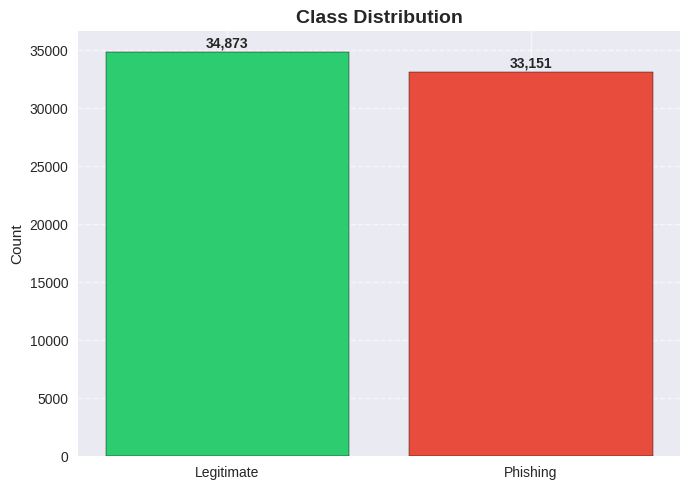

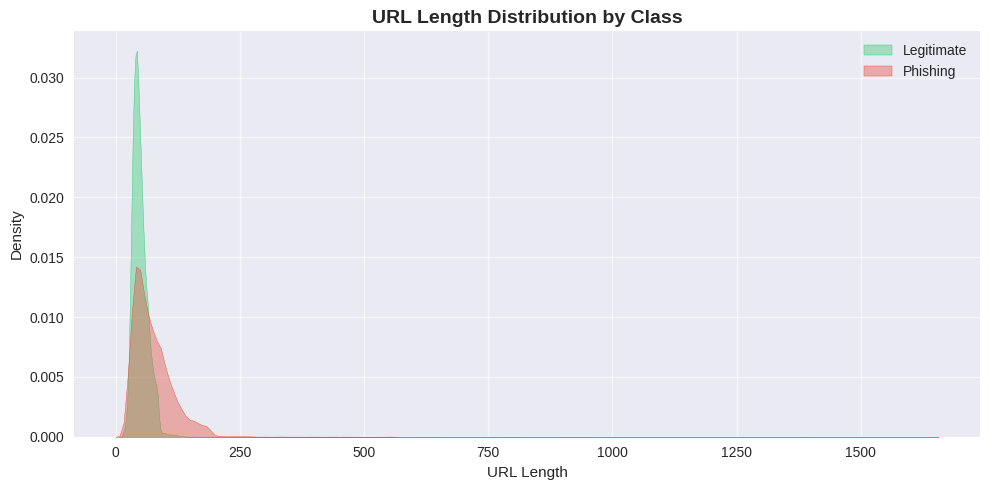

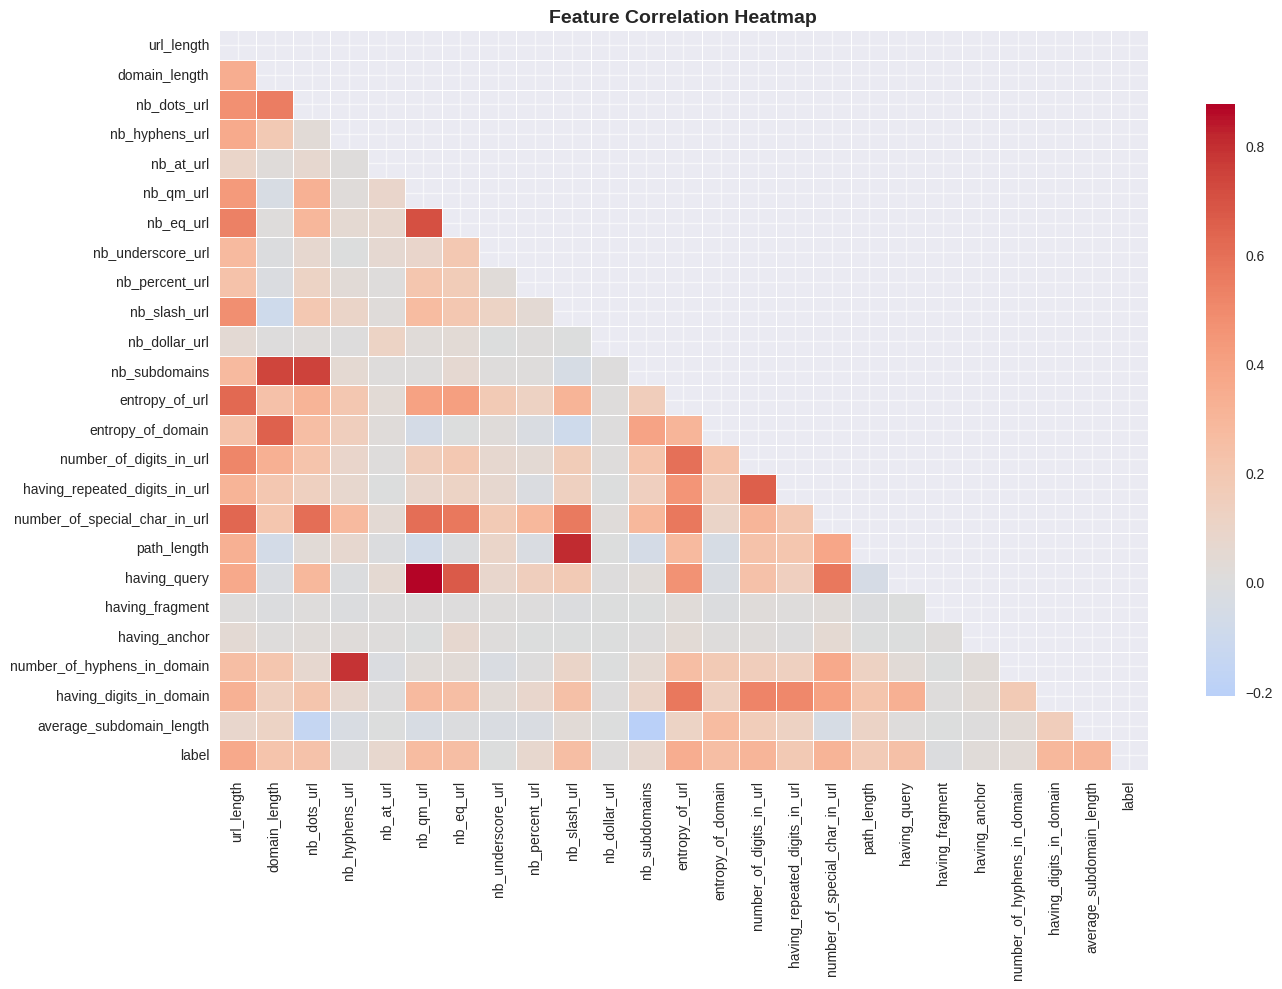

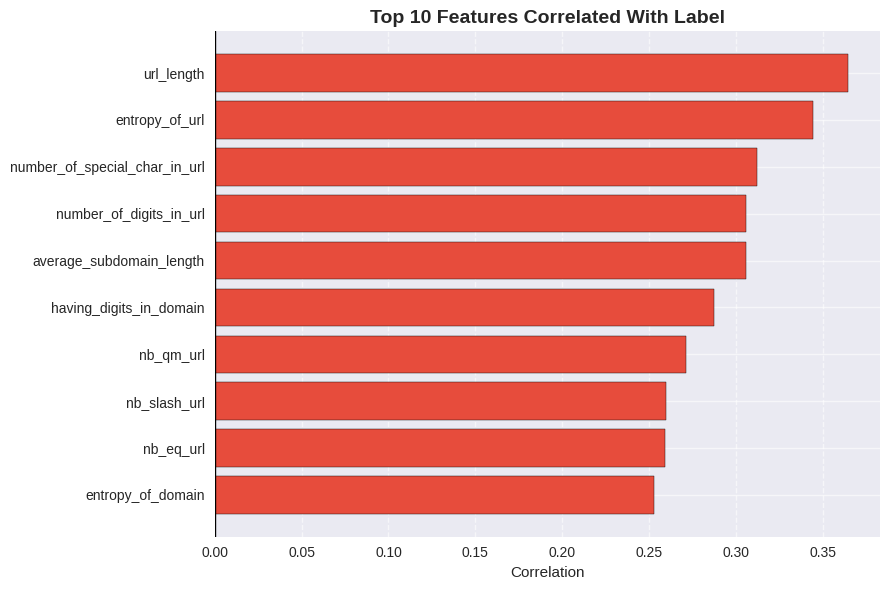

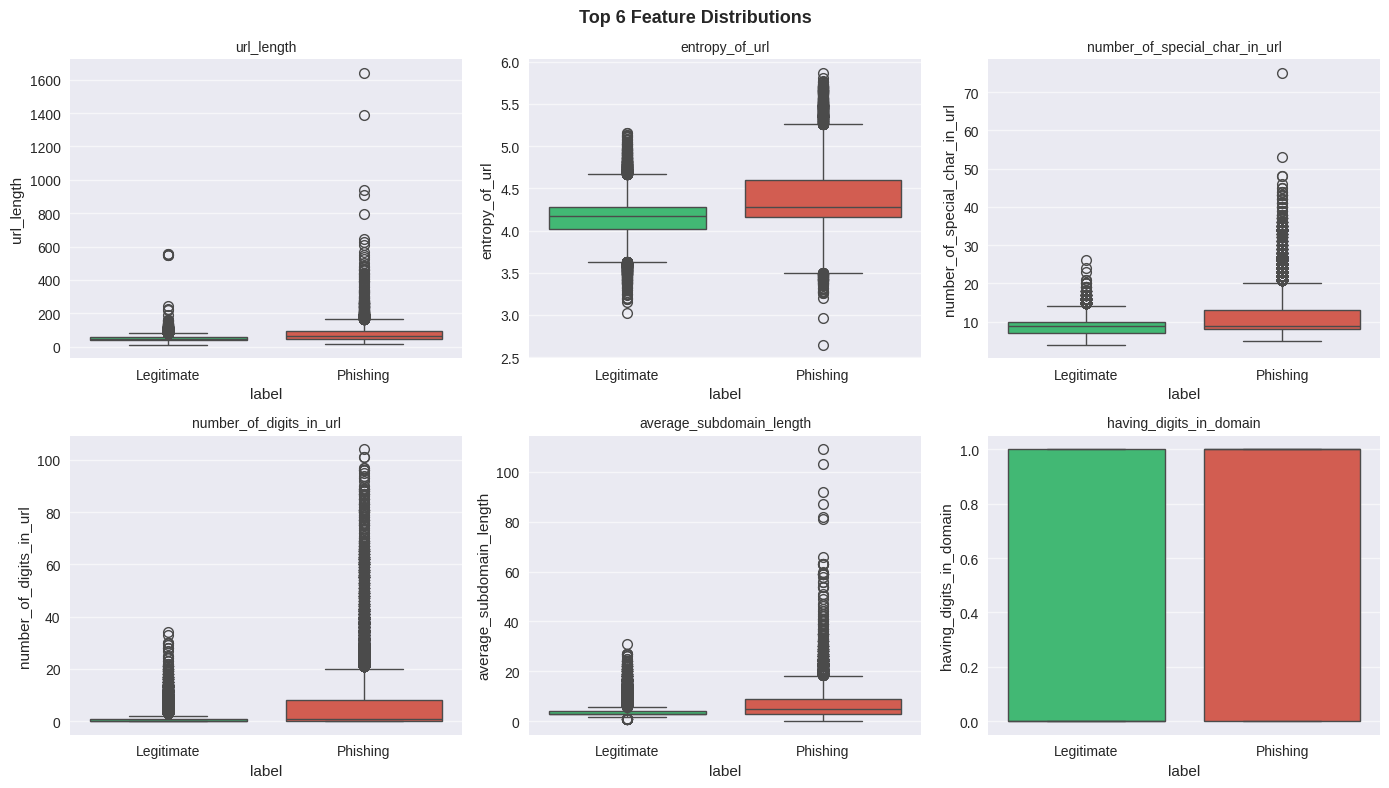

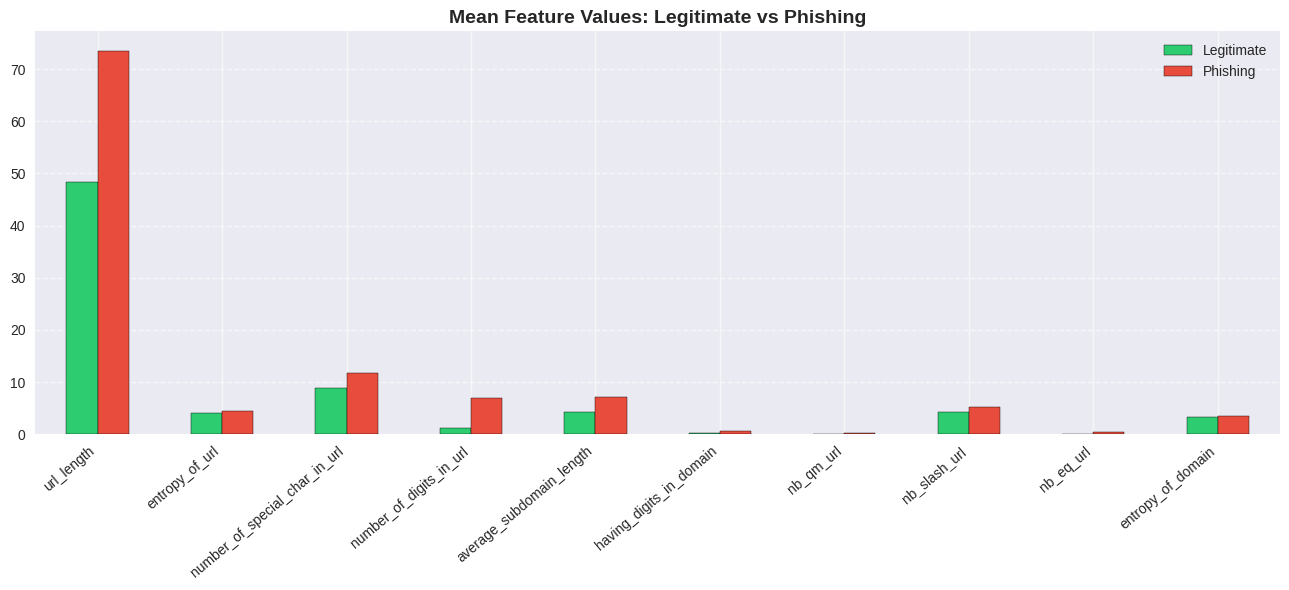


Outlier Check (1% & 99% percentiles):
                                 count       mean        std        min  \
url_length                     68024.0  60.644390  34.595678  12.000000   
domain_length                  68024.0  20.099891  13.011651   0.000000   
nb_dots_url                    68024.0   2.885981   1.701319   0.000000   
nb_hyphens_url                 68024.0   0.731918   1.478746   0.000000   
nb_at_url                      68024.0   0.007571   0.102818   0.000000   
nb_qm_url                      68024.0   0.161869   0.447904   0.000000   
nb_eq_url                      68024.0   0.253043   0.795713   0.000000   
nb_underscore_url              68024.0   0.228169   0.753624   0.000000   
nb_percent_url                 68024.0   0.088733   0.847643   0.000000   
nb_slash_url                   68024.0   4.801820   1.841680   2.000000   
nb_dollar_url                  68024.0   0.000764   0.045035   0.000000   
nb_subdomains                  68024.0   2.157400   1.286740 

In [ ]:
# ── Imports ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Styling ─────────────────────────────────────────────
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")

LEGIT_COLOR = '#2ecc71'
PHISH_COLOR = '#e74c3c'
PALETTE = [LEGIT_COLOR, PHISH_COLOR]

# ── Load Data ───────────────────────────────────────────
df = pd.read_csv('phishing_merged_final.csv')

feature_cols = [c for c in df.columns if c != 'label']

# ── 1. Basic Overview ───────────────────────────────────
print("="*50)
print("DATA OVERVIEW")
print("="*50)

print("\nShape:", df.shape)

print("\nData Types:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nLabel Distribution:")
print(df['label'].value_counts())

print("\nLabel Ratio:")
print(df['label'].value_counts(normalize=True))

print("\nBasic Statistics:")
print(df.describe())

# ── 2. Class Distribution ───────────────────────────────
plt.figure(figsize=(7, 5))
counts = df['label'].value_counts().sort_index()

bars = plt.bar(['Legitimate', 'Phishing'], counts.values,
               color=[LEGIT_COLOR, PHISH_COLOR],
               edgecolor='black')

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.01,
             f'{val:,}',
             ha='center', fontweight='bold')

plt.title("Class Distribution", fontsize=14, fontweight='bold')
plt.ylabel("Count")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── 3. Feature Distribution (Example: URL Length) ───────
if 'url_length' in df.columns:
    plt.figure(figsize=(10, 5))

    for label_val, color, name in zip([0, 1], PALETTE,
                                      ['Legitimate', 'Phishing']):
        sns.kdeplot(df[df['label'] == label_val]['url_length'],
                    fill=True, label=name, alpha=0.4, color=color)

    plt.title("URL Length Distribution by Class", fontsize=14, fontweight='bold')
    plt.xlabel("URL Length")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ── 4. Correlation Heatmap ──────────────────────────────
plt.figure(figsize=(14, 10))

corr = df[feature_cols + ['label']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='coolwarm',
            center=0, linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Feature Importance (Correlation with Label) ──────
label_corr = corr['label'].drop('label').sort_values(key=abs, ascending=False)

top10 = label_corr.head(10)

plt.figure(figsize=(9, 6))
colors = [PHISH_COLOR if v > 0 else LEGIT_COLOR for v in top10.values]

plt.barh(top10.index[::-1], top10.values[::-1],
         color=colors[::-1], edgecolor='black')

plt.axvline(0, color='black', linewidth=1)
plt.title("Top 10 Features Correlated With Label", fontsize=14, fontweight='bold')
plt.xlabel("Correlation")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── 6. Boxplots (Top 6 Features) ───────────────────────
top6 = top10.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, top6):
    sns.boxplot(data=df, x='label', y=col,
                palette=PALETTE, ax=ax)

    ax.set_title(col, fontsize=10)
    ax.set_xticklabels(['Legitimate', 'Phishing'])

plt.suptitle("Top 6 Feature Distributions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 7. Mean Feature Comparison ─────────────────────────
means = df.groupby('label')[top10.index].mean().T
means.columns = ['Legitimate', 'Phishing']

means.plot(kind='bar',
           figsize=(13, 6),
           color=[LEGIT_COLOR, PHISH_COLOR],
           edgecolor='black')

plt.title("Mean Feature Values: Legitimate vs Phishing", fontsize=14, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── 8. Outlier Detection Summary ───────────────────────
print("\nOutlier Check (1% & 99% percentiles):")
print(df.describe(percentiles=[0.01, 0.99]).T)

## Feature Correlation Category Classification (High / Medium / Low)

HIGH correlation features  (|r| >= 0.30): 5
  url_length                                    0.3644
  entropy_of_url                                0.3440
  number_of_special_char_in_url                 0.3117
  number_of_digits_in_url                       0.3055
  average_subdomain_length                      0.3054

MEDIUM correlation features (0.10 <= |r| < 0.30): 10
  having_digits_in_domain                       0.2873
  nb_qm_url                                     0.2710
  nb_slash_url                                  0.2597
  nb_eq_url                                     0.2591
  entropy_of_domain                             0.2529
  having_query                                  0.2429
  nb_dots_url                                   0.2282
  domain_length                                 0.2203
  having_repeated_digits_in_url                 0.1918
  path_length                                   0.1749

LOW correlation features   (|r| < 0.10): 9
  nb_at_url                      

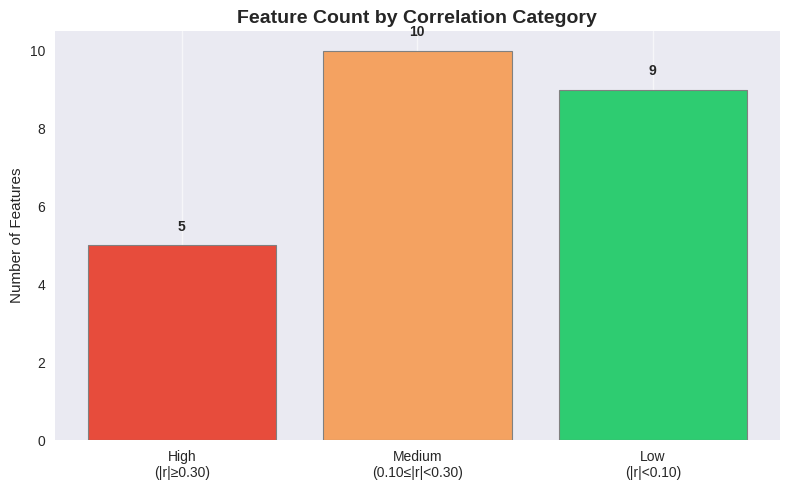

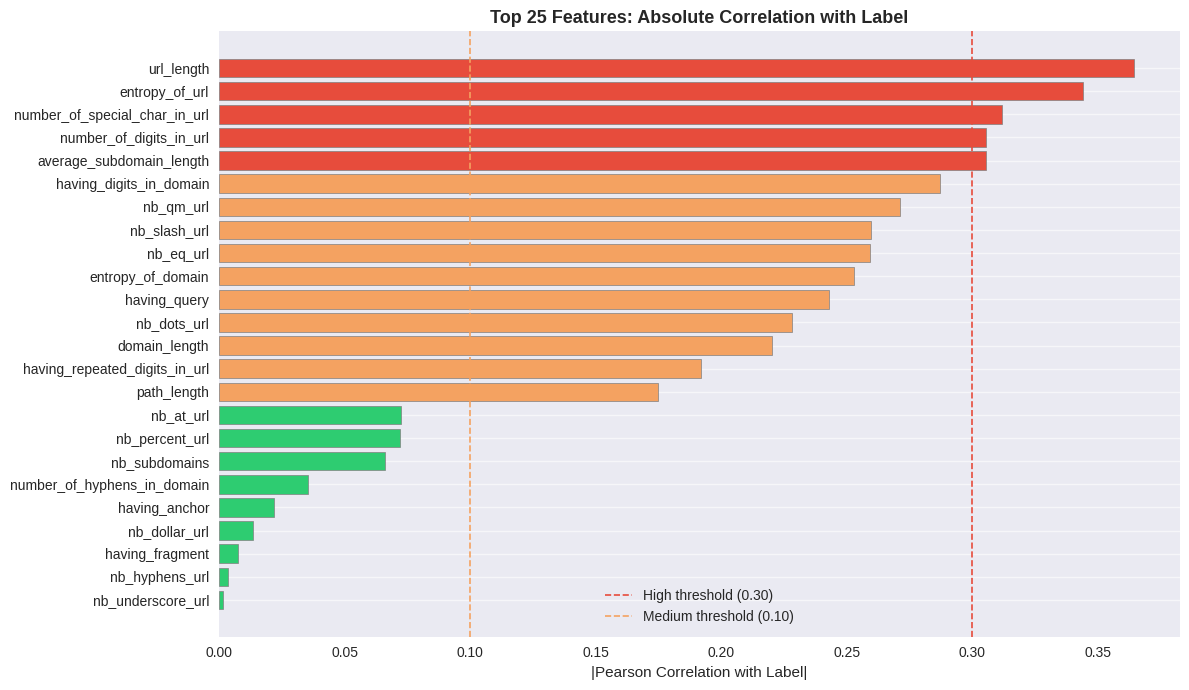


Total features : 24
  High   : 5
  Medium : 10
  Low    : 9


In [ ]:
df = pd.read_csv('phishing_merged_final.csv')
feature_cols = [c for c in df.columns if c != 'label']

label_corr = (df[feature_cols + ['label']].corr()['label']
              .drop('label').abs().sort_values(ascending=False))

high_corr_feats = label_corr[label_corr >= 0.3].index.tolist()
med_corr_feats  = label_corr[(label_corr >= 0.1) & (label_corr < 0.3)].index.tolist()
low_corr_feats  = label_corr[label_corr < 0.1].index.tolist()

print("=" * 60)
print(f"HIGH correlation features  (|r| >= 0.30): {len(high_corr_feats)}")
print("=" * 60)
for f in high_corr_feats:
    print(f"  {f:<45} {label_corr[f]:.4f}")

print(f"\nMEDIUM correlation features (0.10 <= |r| < 0.30): {len(med_corr_feats)}")
print("=" * 60)
for f in med_corr_feats:
    print(f"  {f:<45} {label_corr[f]:.4f}")

print(f"\nLOW correlation features   (|r| < 0.10): {len(low_corr_feats)}")
print("=" * 60)
for f in low_corr_feats:
    print(f"  {f:<45} {label_corr[f]:.4f}")

# ── Summary bar chart ────────────────────────────────────────────────
categories = ['High\n(|r|≥0.30)', 'Medium\n(0.10≤|r|<0.30)', 'Low\n(|r|<0.10)']
counts_cat  = [len(high_corr_feats), len(med_corr_feats), len(low_corr_feats)]
colors_cat  = [PHISH_COLOR, '#F4A261', LEGIT_COLOR]

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts_cat, color=colors_cat, edgecolor='grey', linewidth=0.8)
for bar, val in zip(bars, counts_cat):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontweight='bold')
plt.title("Feature Count by Correlation Category", fontsize=14, fontweight='bold')
plt.ylabel("Number of Features")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# ── Grouped correlation bar chart ─────────────────────────────────────
top_plot = label_corr.head(25)
cat_colors = []
for v in top_plot.values:
    if v >= 0.3:
        cat_colors.append(PHISH_COLOR)
    elif v >= 0.1:
        cat_colors.append('#F4A261')
    else:
        cat_colors.append(LEGIT_COLOR)

plt.figure(figsize=(12, 7))
plt.barh(top_plot.index[::-1], top_plot.values[::-1],
         color=cat_colors[::-1], edgecolor='grey', linewidth=0.5)
plt.axvline(0.3, color=PHISH_COLOR,  linestyle='--', linewidth=1.2, label='High threshold (0.30)')
plt.axvline(0.1, color='#F4A261', linestyle='--', linewidth=1.2, label='Medium threshold (0.10)')
plt.title("Top 25 Features: Absolute Correlation with Label", fontsize=13, fontweight='bold')
plt.xlabel("|Pearson Correlation with Label|")
plt.legend()
plt.grid(axis='x')
plt.tight_layout()
plt.show()

print(f"\nTotal features : {len(feature_cols)}")
print(f"  High   : {len(high_corr_feats)}")
print(f"  Medium : {len(med_corr_feats)}")
print(f"  Low    : {len(low_corr_feats)}")


## Train/Test Split & Baseline Model Training

In [ ]:
# ── Imports ─────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Load Data ───────────────────────────────────────────
df = pd.read_csv('phishing_merged_final.csv')

feature_cols = [c for c in df.columns if c != 'label']
X_full = df[feature_cols]
y_full = df['label']

print(f"Full dataset: {df.shape}")

# ── Subsample (for speed) ───────────────────────────────
SAMPLE_SIZE = 80000

if len(df) > SAMPLE_SIZE:
    print(f"Subsampling {len(df):,} → {SAMPLE_SIZE:,} rows (stratified)...")

    _, X, _, y = train_test_split(
        X_full, y_full,
        test_size=SAMPLE_SIZE / len(df),
        random_state=42,
        stratify=y_full
    )
else:
    X, y = X_full, y_full

# ── Train-Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# ── Models (SVM replaced with LightGBM) ─────────────────
models = {

    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=150,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ),
}

# ── Training & Evaluation ───────────────────────────────
results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...", end=' ', flush=True)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
    })

    print(f"done | Acc={results[-1]['Accuracy']}")

# ── Results Table ───────────────────────────────────────
results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

print("\nBaseline Results:")
print(results_df.to_string(index=False))

# ── Best Model ──────────────────────────────────────────
best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest Baseline Model: {best_model_name}")

Full dataset: (68024, 25)
Train: (54419, 24)  |  Test: (13605, 24)
Training Logistic Regression... done | Acc=0.7812
Training Random Forest... done | Acc=0.8714
Training XGBoost... done | Acc=0.8755
Training LightGBM... done | Acc=0.8727
Training Extra Trees... done | Acc=0.8344

Baseline Results:
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
            XGBoost    0.8755     0.8960  0.8422    0.8683   0.9485
           LightGBM    0.8727     0.8942  0.8379    0.8651   0.9468
      Random Forest    0.8714     0.8994  0.8290    0.8627   0.9436
        Extra Trees    0.8344     0.9096  0.7330    0.8118   0.9154
Logistic Regression    0.7812     0.8198  0.7062    0.7588   0.8492

Best Baseline Model: XGBoost


In [ ]:
print("Best model:", best_model_name)
print("Keys:", list(trained_models.keys()))

Best model: XGBoost
Keys: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'Extra Trees']


## Baseline Model Comparison Plots

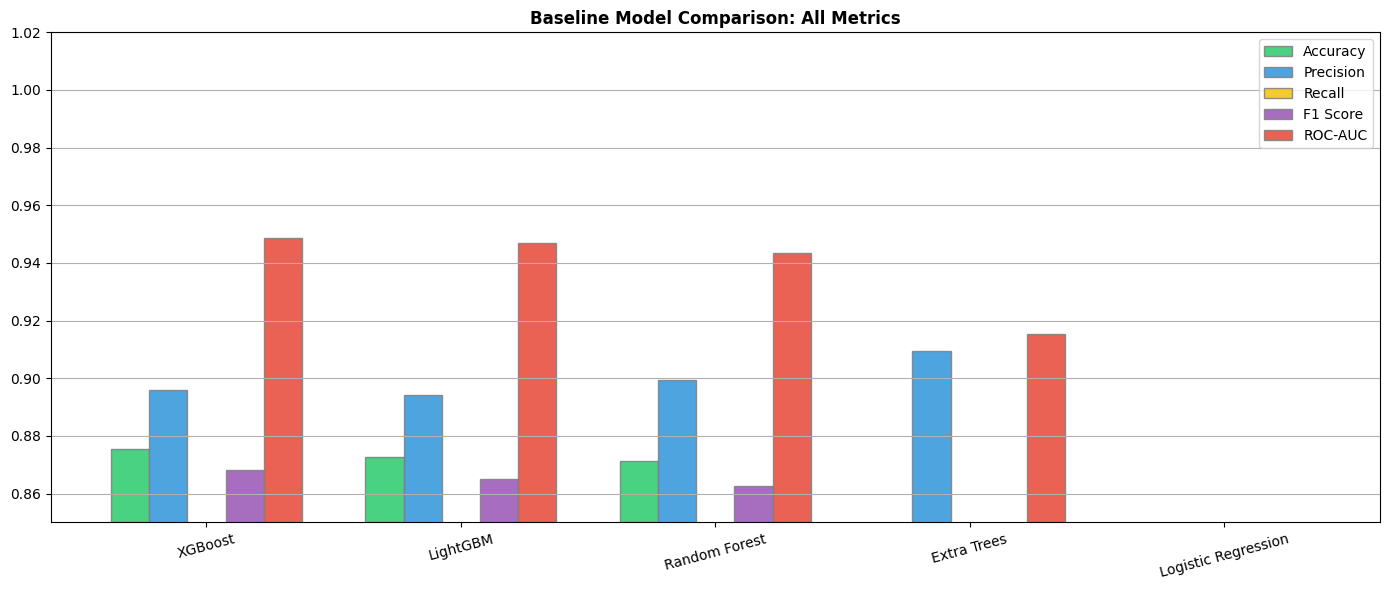

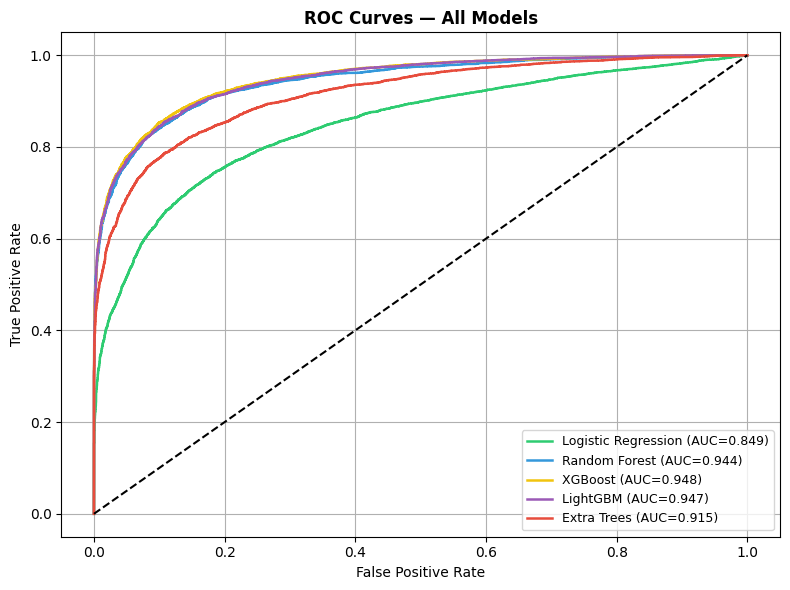

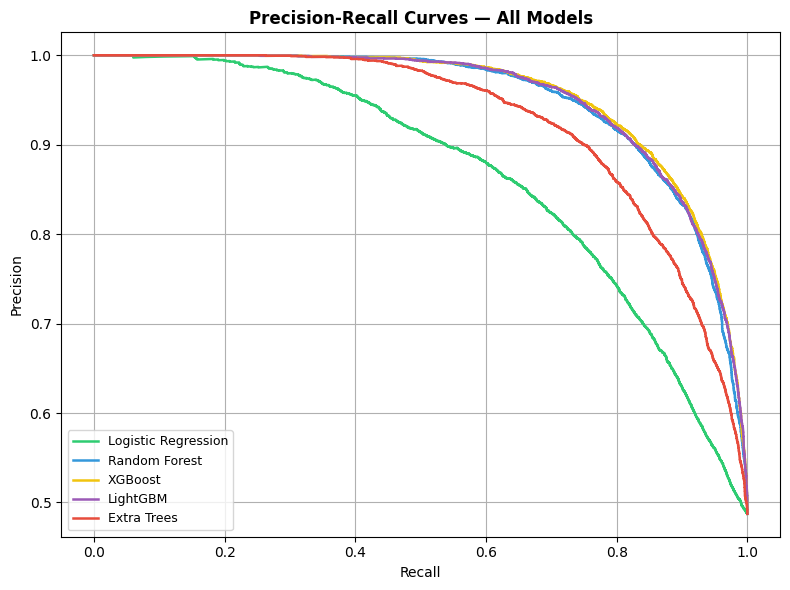

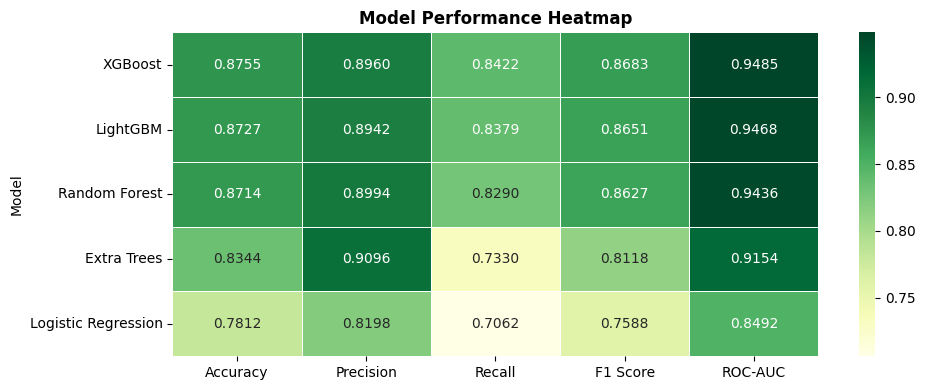

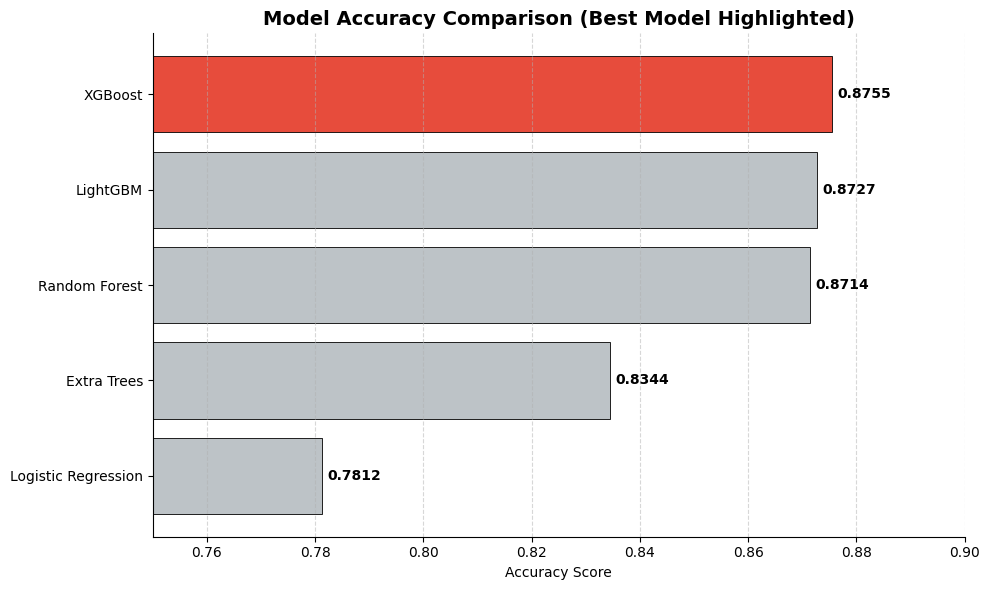

In [ ]:
# ── Required Variables (FIX) ────────────────────────────
metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
COLORS = ['#2ecc71', '#3498db', '#f1c40f', '#9b59b6', '#e74c3c']

# ── Plot 1: Multi-metric Bar Chart ─────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(results_df))
w = 0.15

for i, m in enumerate(metric_cols):
    ax.bar(x + i * w, results_df[m], w,
           label=m, color=COLORS[i],
           alpha=0.88, edgecolor='grey')

ax.set_xticks(x + w * 2)
ax.set_xticklabels(results_df["Model"], rotation=15)
ax.set_ylim(0.85, 1.02)

plt.title('Baseline Model Comparison: All Metrics', fontweight='bold')
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()

# ── Plot 2: ROC Curves ─────────────────────────────────
plt.figure(figsize=(8, 6))

for name, color in zip(trained_models.keys(), COLORS):
    yp = trained_models[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc = roc_auc_score(y_test, yp)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})",
             color=color, lw=1.8)

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models", fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True)

plt.tight_layout()
plt.show()

# ── Plot 3: Precision-Recall Curve ─────────────────────
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8, 6))

for name, color in zip(trained_models.keys(), COLORS):
    yp = trained_models[name].predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, yp)

    plt.plot(rec, prec, label=name, color=color, lw=1.8)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models", fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True)

plt.tight_layout()
plt.show()

# ── Plot 4: Heatmap ────────────────────────────────────
plt.figure(figsize=(10, 4))

heat_data = results_df.set_index("Model")[metric_cols]

sns.heatmap(heat_data, annot=True, fmt='.4f',
            cmap='YlGn', linewidths=0.5)

plt.title("Model Performance Heatmap", fontweight='bold')

plt.tight_layout()
plt.show()

# ── Plot 5: Accuracy Comparison ────────────────────────
# ── Improved Accuracy Comparison ───────────────────────
plt.figure(figsize=(10, 6))

# Sort values (best on top)
sorted_df = results_df.sort_values("Accuracy", ascending=True)

bars = plt.barh(
    sorted_df["Model"],
    sorted_df["Accuracy"],
    color=['#bdc3c7'] * (len(sorted_df) - 1) + ['#e74c3c'],  # highlight best
    edgecolor='black',
    linewidth=0.6
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001,
             bar.get_y() + bar.get_height()/2,
             f"{width:.4f}",
             va='center',
             fontsize=10,
             fontweight='bold')

# Styling
plt.title("Model Accuracy Comparison (Best Model Highlighted)",
          fontsize=14, fontweight='bold')

plt.xlabel("Accuracy Score")
plt.xlim(0.75, 0.90)

# Remove clutter
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Hyperparameter Tuning

Best model: XGBoost

Running Hyperparameter Tuning...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Params: {'colsample_bytree': np.float64(0.9140703845572055), 'learning_rate': np.float64(0.04993475643167195), 'max_depth': 10, 'n_estimators': 443, 'subsample': np.float64(0.836965827544817)}
Best CV Score: 0.9547
Best Threshold: 0.46000000000000013

📊 Performance Comparison:
      Metric  Before   After
0   Accuracy  0.8755  0.8873
1  Precision  0.8960  0.8839
2     Recall  0.8422  0.8851
3   F1 Score  0.8683  0.8845
4    ROC-AUC  0.9485  0.9578


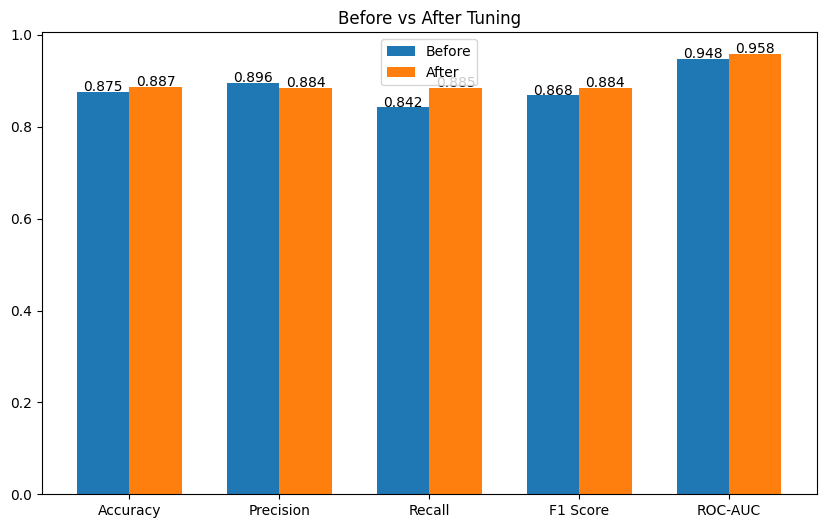

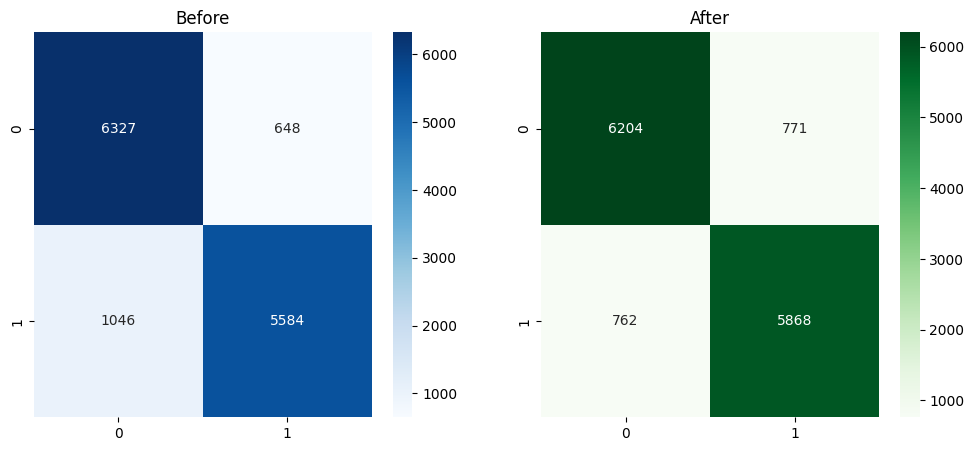

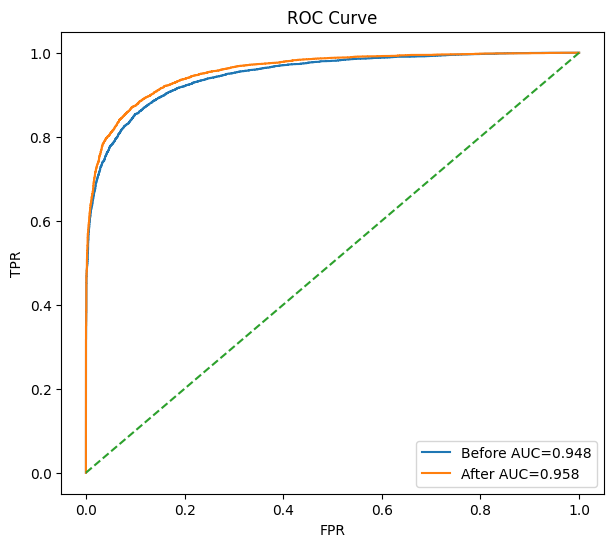

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ───────────────────────────────────────────────────────────────
# SAFETY CHECK
# ───────────────────────────────────────────────────────────────
if len(trained_models) == 0:
    raise ValueError("Run training cell first!")

print("Best model:", best_model_name)

# ───────────────────────────────────────────────────────────────
# BEFORE METRICS
# ───────────────────────────────────────────────────────────────
baseline_model = trained_models[best_model_name]

y_pred_base = baseline_model.predict(X_test)
y_prob_base = baseline_model.predict_proba(X_test)[:, 1]

# ───────────────────────────────────────────────────────────────
# IMPROVED PARAM GRID
# ───────────────────────────────────────────────────────────────
param_grids = {
    "XGBoost": {
        "n_estimators": randint(200, 500),
        "max_depth": randint(4, 12),
        "learning_rate": uniform(0.01, 0.2),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
    }
}

# ───────────────────────────────────────────────────────────────
# CLASS IMBALANCE FIX
# ───────────────────────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ───────────────────────────────────────────────────────────────
# BASE ESTIMATORS
# ───────────────────────────────────────────────────────────────
base_estimators = {
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

# ───────────────────────────────────────────────────────────────
# TUNING
# ───────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nRunning Hyperparameter Tuning...")

search = RandomizedSearchCV(
    estimator=base_estimators.get(best_model_name, baseline_model),
    param_distributions=param_grids.get(best_model_name, {}),
    n_iter=60,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
tuned_model = search.best_estimator_

print("\nBest Params:", search.best_params_)
print("Best CV Score:", round(search.best_score_, 4))

# ───────────────────────────────────────────────────────────────
# THRESHOLD OPTIMIZATION
# ───────────────────────────────────────────────────────────────
probs = tuned_model.predict_proba(X_test)[:, 1]

best_thresh = 0.5
best_f1 = 0

for t in np.arange(0.3, 0.7, 0.01):
    preds = (probs >= t).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best Threshold:", best_thresh)

# ───────────────────────────────────────────────────────────────
# AFTER METRICS
# ───────────────────────────────────────────────────────────────
y_pred_tuned = (probs >= best_thresh).astype(int)
y_prob_tuned = probs

before = [
    accuracy_score(y_test, y_pred_base),
    precision_score(y_test, y_pred_base),
    recall_score(y_test, y_pred_base),
    f1_score(y_test, y_pred_base),
    roc_auc_score(y_test, y_prob_base)
]

after = [
    accuracy_score(y_test, y_pred_tuned),
    precision_score(y_test, y_pred_tuned),
    recall_score(y_test, y_pred_tuned),
    f1_score(y_test, y_pred_tuned),
    roc_auc_score(y_test, y_prob_tuned)
]

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

comparison_df = pd.DataFrame({
    "Metric": metrics,
    "Before": np.round(before, 4),
    "After": np.round(after, 4)
})

print("\n📊 Performance Comparison:")
print(comparison_df)

# ───────────────────────────────────────────────────────────────
# GRAPH 1 — BAR CHART
# ───────────────────────────────────────────────────────────────
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, before, width, label="Before")
plt.bar(x + width/2, after, width, label="After")

plt.xticks(x, metrics)
plt.title("Before vs After Tuning")
plt.legend()

for i, v in enumerate(before):
    plt.text(i - width/2, v + 0.002, f"{v:.3f}", ha='center')

for i, v in enumerate(after):
    plt.text(i + width/2, v + 0.002, f"{v:.3f}", ha='center')

plt.show()

# ───────────────────────────────────────────────────────────────
# GRAPH 2 — CONFUSION MATRIX
# ───────────────────────────────────────────────────────────────
cm_before = confusion_matrix(y_test, y_pred_base)
cm_after = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm_before, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Before")

sns.heatmap(cm_after, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("After")

plt.show()

# ───────────────────────────────────────────────────────────────
# GRAPH 3 — ROC CURVE
# ───────────────────────────────────────────────────────────────
fpr1, tpr1, _ = roc_curve(y_test, y_prob_base)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(7,6))
plt.plot(fpr1, tpr1, label=f"Before AUC={auc(fpr1,tpr1):.3f}")
plt.plot(fpr2, tpr2, label=f"After AUC={auc(fpr2,tpr2):.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()